# Log-Scale KNN Imputation — No Mean, Compressed Range

Problem: raw Euclidean distance lets large-scale attributes (sqft_lot ~ 15000) dominate small-scale ones (bedrooms ~ 3) when choosing the 5 nearest neighbors. Max-scaling to 0–1 was tried and performed worse, because a single outlier max compresses typical values into a narrow band.

Method: **log-scale normalization, no mean**. Each attribute gets one fixed weight learned once from reference data:

- `log_max = log1p(max value in reference data)` per attribute

Normalize: `normalized = log1p(actual) / log_max` (range 0–1, all attributes >= 0 so log1p is safe on zeros). The log compresses extreme outliers while preserving order among typical values. Distance is computed on the normalized matrix so each attribute contributes equally. Unnormalize: `actual = expm1(normalized * log_max)` to return to original units before price prediction.

Same idea for price: `price_log_max = log1p(max price)`, `normalized_price = log1p(price) / price_log_max`, `price = expm1(normalized_price * price_log_max)`.

Flow:
1. Compute log_max weights from reference data (`kc_house_data.csv`) — one per attribute.
2. Log-normalize reference, fit KNN imputer (k=5, distance-weighted) on the normalized matrix.
3. For new data (`future_unseen_examples.csv`): log-normalize with stored weights → impute in normalized space → expm1 back with same weights → predict price, then demonstrate price weight round-trip.

In [9]:
import json
import pathlib
import pickle

import pandas as pd

REQUEST_COLS = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "sqft_above", "sqft_basement"]
DATA_DIR = pathlib.Path("../src/data")
MODEL_DIR = pathlib.Path("../src/model")

# 1. Reference data: fixed weights are learned here once
ref = pd.read_csv(DATA_DIR / "kc_house_data.csv", usecols=REQUEST_COLS + ["price"])
print(f"Reference shape: {ref.shape}")
ref.head()

Reference shape: (21613, 8)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement
0,221900.0,3,1.00,1180,5650,1.0,1180,0
1,538000.0,3,2.25,2570,7242,2.0,2170,400
2,180000.0,2,1.00,770,10000,1.0,770,0
3,604000.0,4,3.00,1960,5000,1.0,1050,910
4,510000.0,3,2.00,1680,8080,1.0,1680,0


In [18]:
# 2. Fixed weights: log1p(max) per attribute (no mean anywhere). log1p is safe on zeros.
import numpy as np
from sklearn.impute import KNNImputer

log_max = np.log1p(ref[REQUEST_COLS].max())
log_max_vec = log_max.to_numpy()
price_log_max = float(np.log1p(ref["price"].max()))
print("Fixed weights (log1p(max); normalized = log1p(actual) / log_max):")
print(log_max.to_string())
print(f"price_log_max: {price_log_max:.4f} (max price {ref['price'].max():,.0f})")

# 3. Fit KNN distance model on the log-normalized matrix (numpy: no feature-name warnings)
N_NEIGHBORS = 5
ref_norm = np.log1p(ref[REQUEST_COLS].to_numpy()) / log_max_vec
imputer_scaled = KNNImputer(n_neighbors=N_NEIGHBORS, weights="distance").fit(ref_norm)
print(f"Scaled KNN fitted on log-normalized matrix: k={N_NEIGHBORS}")

# Raw baseline for comparison (distance in original units)
imputer_raw = KNNImputer(n_neighbors=N_NEIGHBORS, weights="distance").fit(ref[REQUEST_COLS].to_numpy())
print("Raw KNN fitted for comparison")

Fixed weights (log1p(max); normalized = log1p(actual) / log_max):
bedrooms          3.526361
bathrooms         2.197225
sqft_living       9.513477
sqft_lot         14.317110
floors            1.504077
sqft_above        9.149634
sqft_basement     8.480737
price_log_max: 15.8567 (max price 7,700,000)
Scaled KNN fitted on log-normalized matrix: k=5
Raw KNN fitted for comparison


In [19]:
# 4. Helpers: log1p / weight → impute → expm1 back (numpy: no feature-name warnings)
def impute_scaled(frame: pd.DataFrame) -> pd.DataFrame:
    """Fill missing REQUEST_COLS via KNN on the log-normalized matrix, return actual units."""
    norm = np.log1p(frame[REQUEST_COLS].to_numpy()) / log_max_vec
    filled_norm = imputer_scaled.transform(norm)
    out = frame.copy()
    out[REQUEST_COLS] = np.expm1(filled_norm * log_max_vec)
    return out


def impute_raw(frame: pd.DataFrame) -> pd.DataFrame:
    """Baseline: KNN directly in original units."""
    out = frame.copy()
    out[REQUEST_COLS] = imputer_raw.transform(frame[REQUEST_COLS].to_numpy())
    return out

## 5. Test on `future_unseen_examples.csv`

That file has no missing values, so we mask 15% per column (MCAR) to create ground truth, then compare raw vs scaled imputation.

In [20]:
import numpy as np
from sklearn.metrics import mean_squared_error

future = pd.read_csv(DATA_DIR / "future_unseen_examples.csv")
print(f"Future shape: {future.shape}, missing: {future.isna().sum().sum()}")

rng = np.random.default_rng(42)
mask = pd.DataFrame(data=False, index=future.index, columns=REQUEST_COLS)
for col in REQUEST_COLS:
    idx = rng.choice(future.index, size=int(len(future) * 0.15), replace=False)
    mask.loc[idx, col] = True
masked = future.copy()
masked[REQUEST_COLS] = future[REQUEST_COLS].mask(mask)
print(f"Masked cells: {mask.sum().sum()}")

filled_raw = impute_raw(masked)
filled_scaled = impute_scaled(masked)
print(f"Remaining NaN — raw: {filled_raw[REQUEST_COLS].isna().sum().sum()}, scaled: {filled_scaled[REQUEST_COLS].isna().sum().sum()}")

rows = []
for col in REQUEST_COLS:
    m = mask[col]
    rmse_raw = float(np.sqrt(mean_squared_error(future.loc[m, col], filled_raw.loc[m, col])))
    rmse_scaled = float(np.sqrt(mean_squared_error(future.loc[m, col], filled_scaled.loc[m, col])))
    improvement = 100 * (rmse_raw - rmse_scaled) / rmse_raw if rmse_raw > 0 else 0.0
    rows.append({"feature": col, "raw_RMSE": rmse_raw, "scaled_RMSE": rmse_scaled, "improvement_pct": improvement})
cmp = pd.DataFrame(rows).round(3)
cmp

Future shape: (100, 18), missing: 0
Masked cells: 105
Remaining NaN — raw: 0, scaled: 0


,feature,raw_RMSE,scaled_RMSE,improvement_pct
0,bedrooms,0.213,0.170,19.977
1,bathrooms,0.058,0.043,25.127
2,sqft_living,46.992,39.547,15.843
3,sqft_lot,10116.588,10503.723,-3.827
4,floors,0.000,0.000,0.000
5,sqft_above,8.262,12.502,-51.318
6,sqft_basement,55.255,2.726,95.067


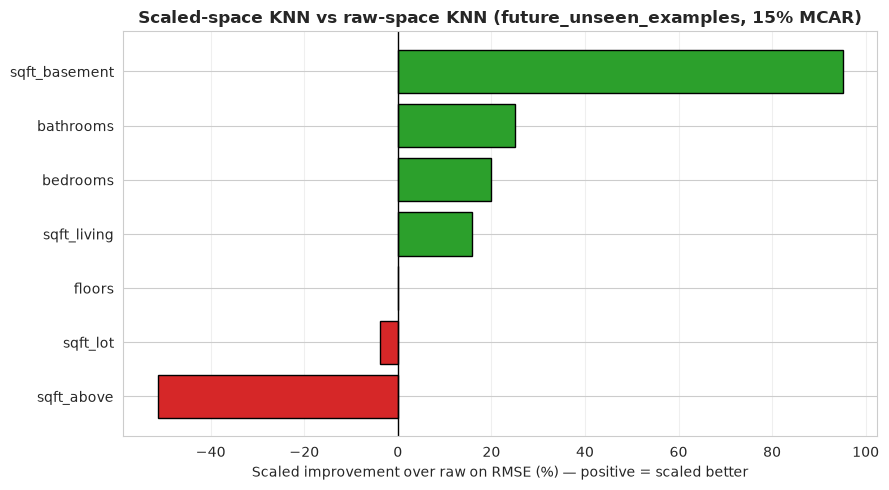

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
ordered = cmp.sort_values("improvement_pct")
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#2ca02c" if v > 0 else "#d62728" for v in ordered["improvement_pct"]]
ax.barh(ordered["feature"], ordered["improvement_pct"], color=bar_colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Scaled improvement over raw on RMSE (%) — positive = scaled better")
ax.set_title("Scaled-space KNN vs raw-space KNN (future_unseen_examples, 15% MCAR)", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. End-to-end: unnormalized values → price prediction

Imputed values are converted back to original units with the same fixed multipliers, joined to demographics, then fed to the stored price model.

In [22]:
# Trusted build artifact from src/model/create_model.py (same process, not untrusted input)
with (MODEL_DIR / "model.pkl").open("rb") as f:
    price_model = pickle.load(f)  # noqa: S301
with (MODEL_DIR / "model_features.json").open() as f:
    model_features = json.load(f)
demographics = pd.read_csv(DATA_DIR / "zipcode_demographics.csv", dtype={"zipcode": str})
print(f"Model expects {len(model_features)} features")

# Use scaled-imputed rows (actual units after expm1), join demographics, predict
demo = filled_scaled[["zipcode"]].astype({"zipcode": str}).merge(demographics, how="left", on="zipcode")
predict_frame = pd.concat([filled_scaled[REQUEST_COLS].reset_index(drop=True), demo.drop(columns="zipcode").reset_index(drop=True)], axis=1)
predict_frame = predict_frame[model_features]
prices = price_model.predict(predict_frame)

# Price weight round-trip: normalized = log1p(price) / price_log_max, price = expm1(normalized * price_log_max)
norm_prices = np.log1p(prices) / price_log_max
round_trip = np.expm1(norm_prices * price_log_max)
print(f"price_log_max={price_log_max:.4f}; round-trip max abs diff={abs(round_trip - prices).max():.6f}")

out = future[["zipcode"]].copy()
out["predicted_price_scaled_imputed"] = prices
out["predicted_price_normalized"] = norm_prices
print(out.head(10).to_string(index=False))
print(f"\nPredicted {len(out)} prices; mean=${prices.mean():,.0f} min=${prices.min():,.0f} max=${prices.max():,.0f}")

Model expects 33 features
price_log_max=15.8567; round-trip max abs diff=0.000000
 zipcode  predicted_price_scaled_imputed  predicted_price_normalized
   98118                        458520.0                    0.822096
   98115                        612800.0                    0.840387
   98030                        449160.0                    0.820796
   98005                        679700.0                    0.846922
   98126                        304256.0                    0.796231
   98028                        553798.0                    0.834003
   98178                        341800.0                    0.803569
   98125                        445350.0                    0.820258
   98112                        990500.0                    0.870669
   98074                        532940.0                    0.831582

Predicted 100 prices; mean=$479,708 min=$180,290 max=$1,241,796
